# 04 — Tree models: Decision Tree, Random Forest, XGBoost
**EM 630 · Electricity Demand Forecasting · Phase 5**

**Question.** Can non-linear models beat the best linear model (Lasso + hour×month, **64.9 MW**) and the baseline bar (**74.3 MW**)?

**Why trees?** Phase 4 needed 253 hand-made hour×month interaction columns before a linear model could follow the seasonal change in daily shape. A tree finds interactions **by itself**: a split on `month` followed by a split on `hour` *is* an interaction.

**Expectations written down before running**
1. A single tree overfits easily and will not beat the linear model.
2. Random Forest (bagging) beats a single tree by reducing variance.
3. XGBoost (boosting) is the best tree model and beats 64.9 MW.

In [1]:
import sys, inspect, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
from src import config, data, features, split, tree_models as tm
pd.set_option("display.precision", 3)
def show(name, width=950):
    display(Image(filename=str(config.FIG_DIR / f"{name}.png"), width=width))
sp = split.chronological_split(features.build_features(data.load_clean()))
F = features.FEATURE_SETS["tree"]
print(f"{len(F)} tree features:", F)

28 tree features: ['hour', 'dow', 'month', 'dayofyear', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_festival', 'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_24', 'load_lag_48', 'load_lag_168', 'load_roll_mean_24', 'load_roll_std_24', 'load_roll_mean_168', 'load_ramp_1', 'temp_lag_1', 'humidity_lag_1', 'temp_roll_mean_24', 'weather_lag_1_cloudy', 'weather_lag_1_rain', 'weather_lag_1_storm']


Trees use the **raw** calendar integers (`hour`, `month`, …): a tree splits on thresholds such as `hour ≤ 8.5`, so an ordinal integer is perfectly usable and no one-hot encoding or scaling is needed. They also keep `load_ramp_1`, the exact duplicate that had to be removed for linear models: trees don't invert $X^\top X$, so collinearity doesn't break them, and a ready-made difference saves them several splits. (See `FEATURES.md`.)

---
## 1. The three algorithms

| | How it fits | Main hyperparameters | Course link |
|---|---|---|---|
| **Decision tree** | Greedy recursive splits; each split picks the feature/threshold that most reduces squared error | `max_depth`, `min_samples_leaf` | complexity control, bias–variance |
| **Random Forest** | Average of many deep trees, each on a bootstrap sample with a random subset of features per split (**bagging**) | `max_features`, `min_samples_leaf`, depth | averaging de-correlated estimators reduces **variance** |
| **XGBoost** | Trees added one at a time; tree $m$ fits the **negative gradient** of the loss (for squared error, the current residuals): $F_m(x)=F_{m-1}(x)+\eta\, f_m(x)$ | learning rate $\eta$, number of trees, depth, `reg_lambda` (L2), `reg_alpha` (L1), subsampling | **gradient descent in function space**; L1/L2 penalties on leaf weights = Ridge/Lasso ideas |

---
## 2. A design choice made by cross-validation: predict the *level* or the *change*?

A tree's prediction is an **average of training targets** in a leaf, so a "level" tree can never forecast above the highest load it saw in training. Predicting the **hourly change** $d_h = y_h - y_{h-1}$ and adding back `load_lag_1` avoids that ceiling, and each leaf then holds a small, stationary quantity. Rather than choosing by hand, we made `target ∈ {level, delta}` **a hyperparameter**, chosen by CV:

In [2]:
print(inspect.getsource(tm.TargetMode))

class TargetMode(BaseEstimator, RegressorMixin):
    """Wraps a regressor so that the target can be the level or the hourly change.
    Behaves like a normal sklearn estimator, so `target` can be tuned in a CV search."""

    def __init__(self, regressor=None, target: str = "level"):
        self.regressor = regressor
        self.target = target

    def fit(self, X, y):
        self.regressor_ = clone(self.regressor)
        y_t = y - X[LAG1] if self.target == "delta" else y
        self.regressor_.fit(X, y_t)
        self.feature_names_in_ = np.asarray(X.columns)
        return self

    def predict(self, X):
        p = self.regressor_.predict(X)
        return p + X[LAG1].values if self.target == "delta" else p



A test confirms the ceiling (`test_level_tree_cannot_exceed_training_max`): a level tree fed an artificial heatwave never predicts above the training maximum.
*Honesty note:* in **this** test period the load never exceeds the training maximum (7,610 vs 8,632 MW), so the ceiling is **not** why "delta" wins here. The gain comes from the finer resolution of predicting small steps (Fig 22).

---
## 3. Hyperparameter tuning

Randomised search with the same forward-chaining 5-fold CV as Phase 4, scored by MAE. **Stage 1** searches a broad grid. Where stage 1 chose a value at the **edge** of its grid, **stage 2** searches past that edge. A stage-2 model replaces stage 1 only if its CV error is lower. The test set is never consulted. Stopping rule, fixed in advance: one refinement stage only.

In [3]:
for n, g in tm.SEARCH.items():
    print(n, {k.replace('regressor__', ''): v for k, v in g.items()})

Decision Tree {'max_depth': [6, 8, 10, 12, 15, 20, None], 'min_samples_leaf': [1, 5, 10, 20, 50, 100], 'target': ['level', 'delta']}
Random Forest {'max_depth': [12, 18, None], 'min_samples_leaf': [1, 3, 10], 'max_features': [0.33, 0.6, 1.0], 'target': ['level', 'delta']}
XGBoost {'n_estimators': [300, 600, 1000, 1500], 'learning_rate': [0.02, 0.05, 0.1], 'max_depth': [4, 6, 8, 10], 'min_child_weight': [1, 5, 20], 'subsample': [0.7, 0.85, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0], 'reg_lambda': [0.1, 1, 10], 'reg_alpha': [0, 1, 10], 'target': ['level', 'delta']}


In [4]:
# stage-2 grids (searched past the stage-1 edges); see scripts/run_phase5_refine.py
src = open("../scripts/run_phase5_refine.py").read()
print(src[src.index("STAGE2 = {"):src.index("best1 =")].split("# keep stage-1")[0])
pd.read_csv(config.TABLE_DIR / "phase5_stage2_log.csv")

STAGE2 = {
    "Random Forest": ({
        "regressor__max_features": [0.15, 0.2, 0.25, 0.33],
        "regressor__min_samples_leaf": [1],
        "regressor__max_depth": [18, 24],
        "target": ["delta"],
    }, 8),
    "XGBoost": ({
        "regressor__learning_rate": [0.01, 0.02],
        "regressor__n_estimators": [600, 1000, 1500, 2500],
        "regressor__max_depth": [10, 12, 14],
        "regressor__min_child_weight": [20, 50, 100],
        "regressor__colsample_bytree": [0.4, 0.5, 0.6],
        "regressor__reg_lambda": [0.01, 0.1],
        "regressor__subsample": [0.85],
        "regressor__reg_alpha": [0],
        "target": ["delta"],
    }, 24),
}




,model,split,cv_mae_stage1,cv_mae_stage2,replaced,target,min_samples_leaf,max_features,max_depth,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,learning_rate,colsample_bytree
0,Random Forest,val,75.349,75.349,False,delta,1.0,0.33,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,test,73.962,73.962,False,delta,1.0,0.33,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost,val,77.954,77.160,True,delta,NaN,NaN,14,0.85,0.1,0.0,1000.0,20.0,0.01,0.5
3,XGBoost,test,77.174,76.063,True,delta,NaN,NaN,10,0.85,0.1,0.0,600.0,50.0,0.01,0.5


In [5]:
pd.read_csv(config.TABLE_DIR / "phase5_best_params.csv").set_index(["model", "split"]).T

model            Decision Tree         Random Forest                  XGBoost  \
split                      val    test           val    test              val   
cv_mae                  92.135  87.902        75.349  73.962            77.16   
n_iter                      30      30             8      14  20+24 (stage 2)   
target                   delta   delta         delta   delta            delta   
min_samples_leaf          10.0    10.0           1.0     1.0              NaN   
max_depth                   20      20            18      18               14   
max_features               NaN     NaN          0.33    0.33              NaN   
subsample                  NaN     NaN           NaN     NaN             0.85   
reg_lambda                 NaN     NaN           NaN     NaN              0.1   
reg_alpha                  NaN     NaN           NaN     NaN              0.0   
n_estimators               NaN     NaN           NaN     NaN           1000.0   
min_child_weight           NaN     NaN           NaN     NaN             20.0   
learning_rate              NaN     NaN           NaN     NaN             0.01   
colsample_bytree           NaN     NaN           NaN     NaN              0.5   

model                              
split                        test  
cv_mae                     76.063  
n_iter            40+24 (stage 2)  
target                      delta  
min_samples_leaf              NaN  
max_depth                      10  
max_features                  NaN  
subsample                    0.85  
reg_lambda                    0.1  
reg_alpha                     0.0  
n_estimators                600.0  
min_child_weight             50.0  
learning_rate                0.01  
colsample_bytree              0.5

---
## 4. One tree: watching it overfit

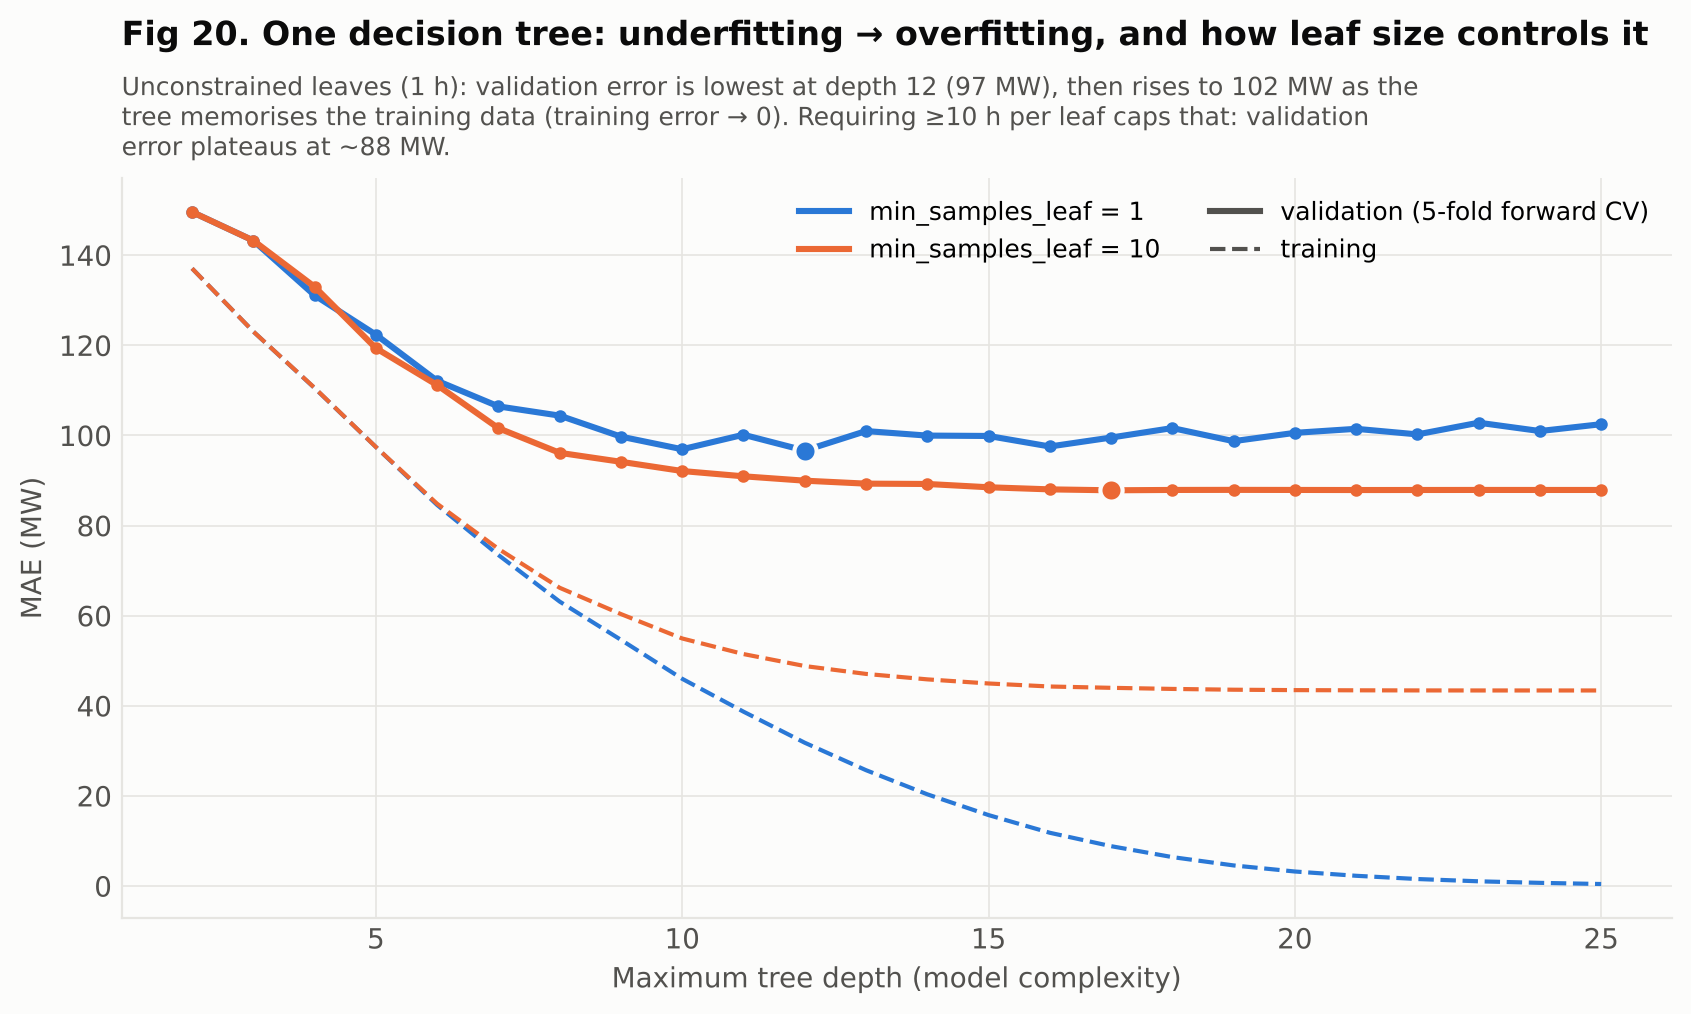

In [6]:
show("F20_tree_depth_sweep")

💡 **Bias–variance for trees.** Shallow trees underfit (high bias): they can't represent the hour × season pattern. Deep trees memorise the training data (training error keeps falling) but generalise worse (validation error rises). Depth plays the same role for trees that α played for Ridge: it controls complexity.

---
## 5. Boosting = gradient descent

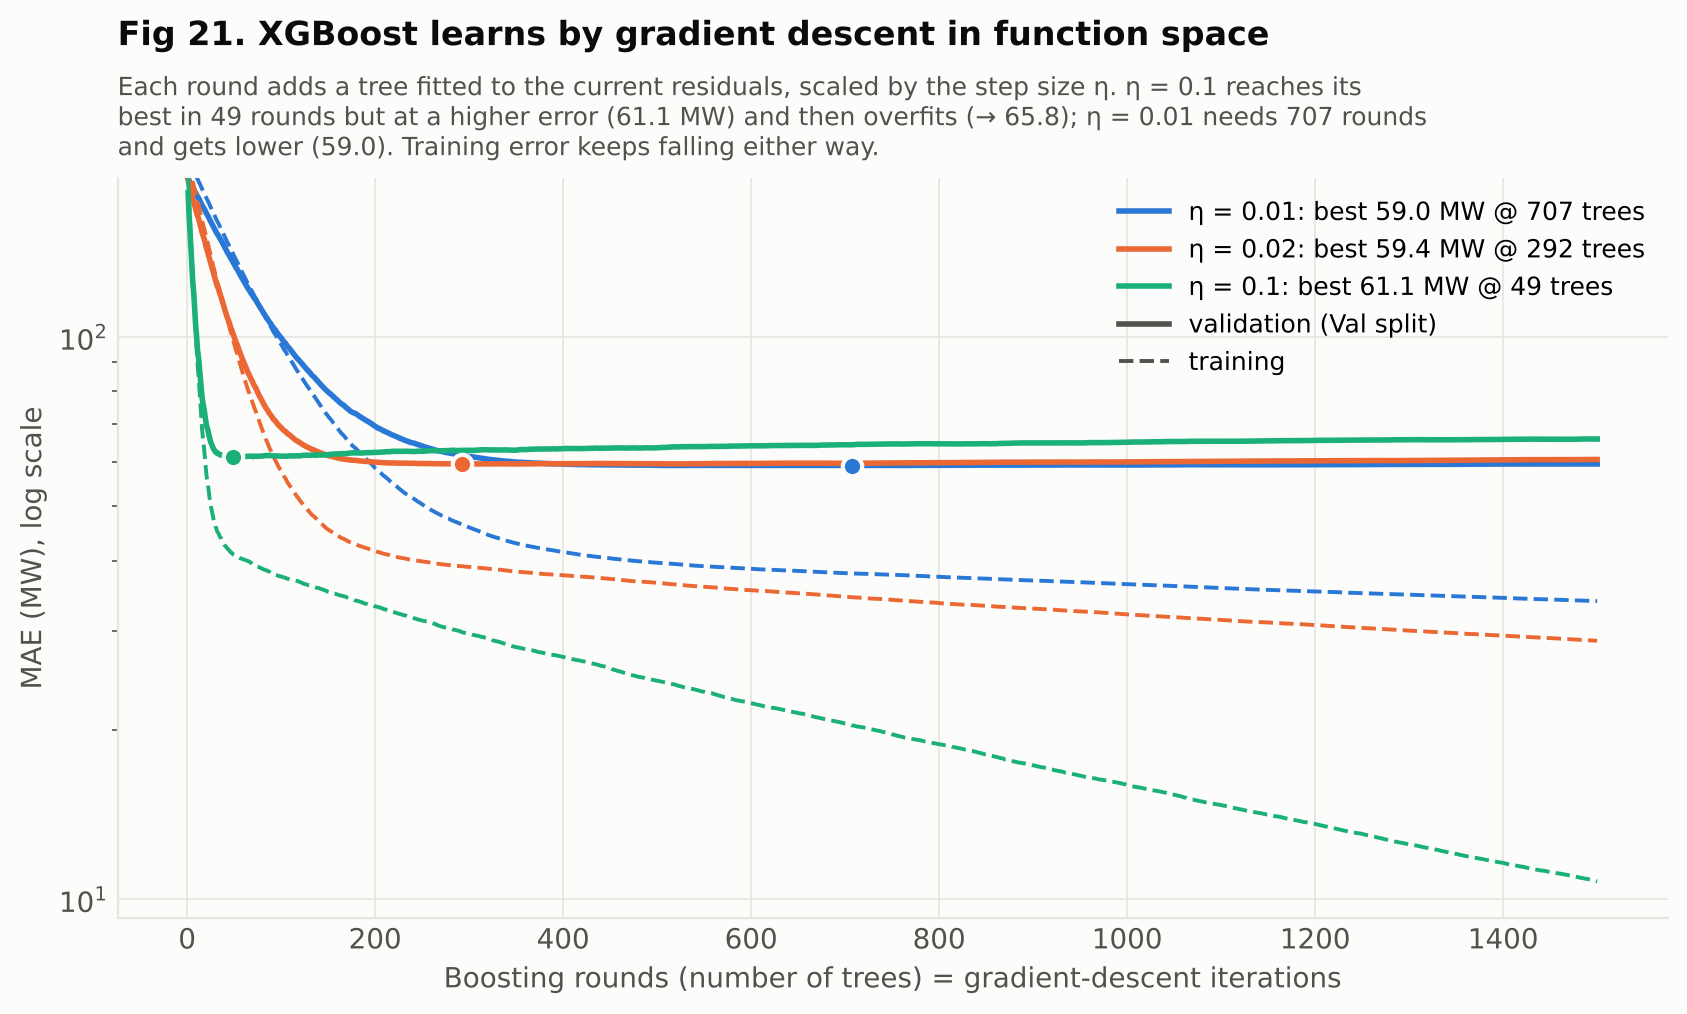

In [7]:
show("F21_boosting_curve")

💡 Each boosting round is one gradient step, taken in the space of functions rather than parameters. The **learning rate η** is the step size, exactly as in gradient descent on weights. A small η needs many rounds but reaches a lower validation error; a large η descends fast and plateaus higher. The **number of trees** acts like the number of epochs: past the validation minimum, extra rounds only fit noise (the training curve keeps falling, the validation curve doesn't).

---
## 6. Results on the test set

In [8]:
tab = pd.read_csv(config.TABLE_DIR / "phase5_trees.csv")
cols = ["model", "MAE", "RMSE", "MAPE", "R2", "Bias", "skill_vs_naive1", "skill_vs_step", "skill_vs_lasso"]
tab[(tab.split == "test") & (tab.subset == "all")][cols].sort_values("MAE").reset_index(drop=True)

,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1,skill_vs_step,skill_vs_lasso
0,XGBoost,51.734,76.165,1.204,0.997,1.125,0.747,0.304,0.203
1,Random Forest,51.908,76.432,1.208,0.997,1.098,0.746,0.301,0.200
2,XGBoost [level target],64.641,89.928,1.494,0.995,2.281,0.684,0.130,0.004
3,Lasso + hour×month,64.913,92.030,1.558,0.995,5.077,0.683,0.127,0.000
4,Decision Tree,67.839,98.563,1.586,0.994,1.831,0.669,0.087,-0.045
5,Random Forest [level target],71.682,98.262,1.653,0.994,-0.112,0.650,0.035,-0.104
6,Naive-1 + hourly step,74.313,104.284,1.774,0.994,2.158,0.637,0.000,-0.145
7,Decision Tree [level target],95.699,132.311,2.247,0.990,1.704,0.532,-0.288,-0.474
8,Naive-1 (persistence),204.685,265.201,5.055,0.959,0.424,0.000,-1.754,-2.153


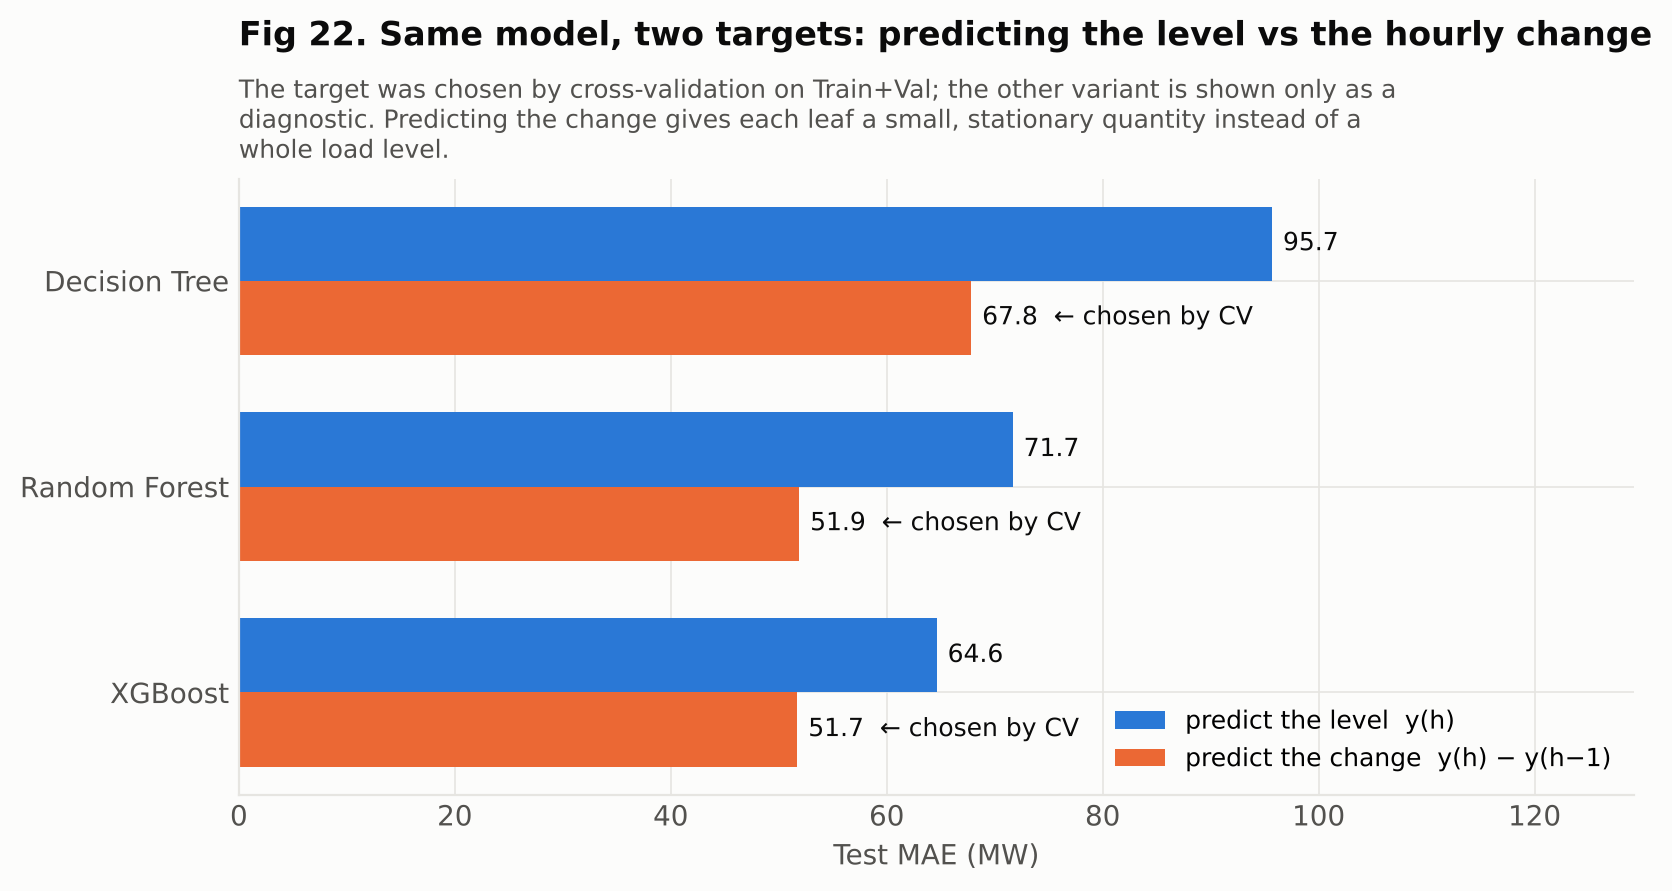

In [9]:
show("F22_level_vs_delta")

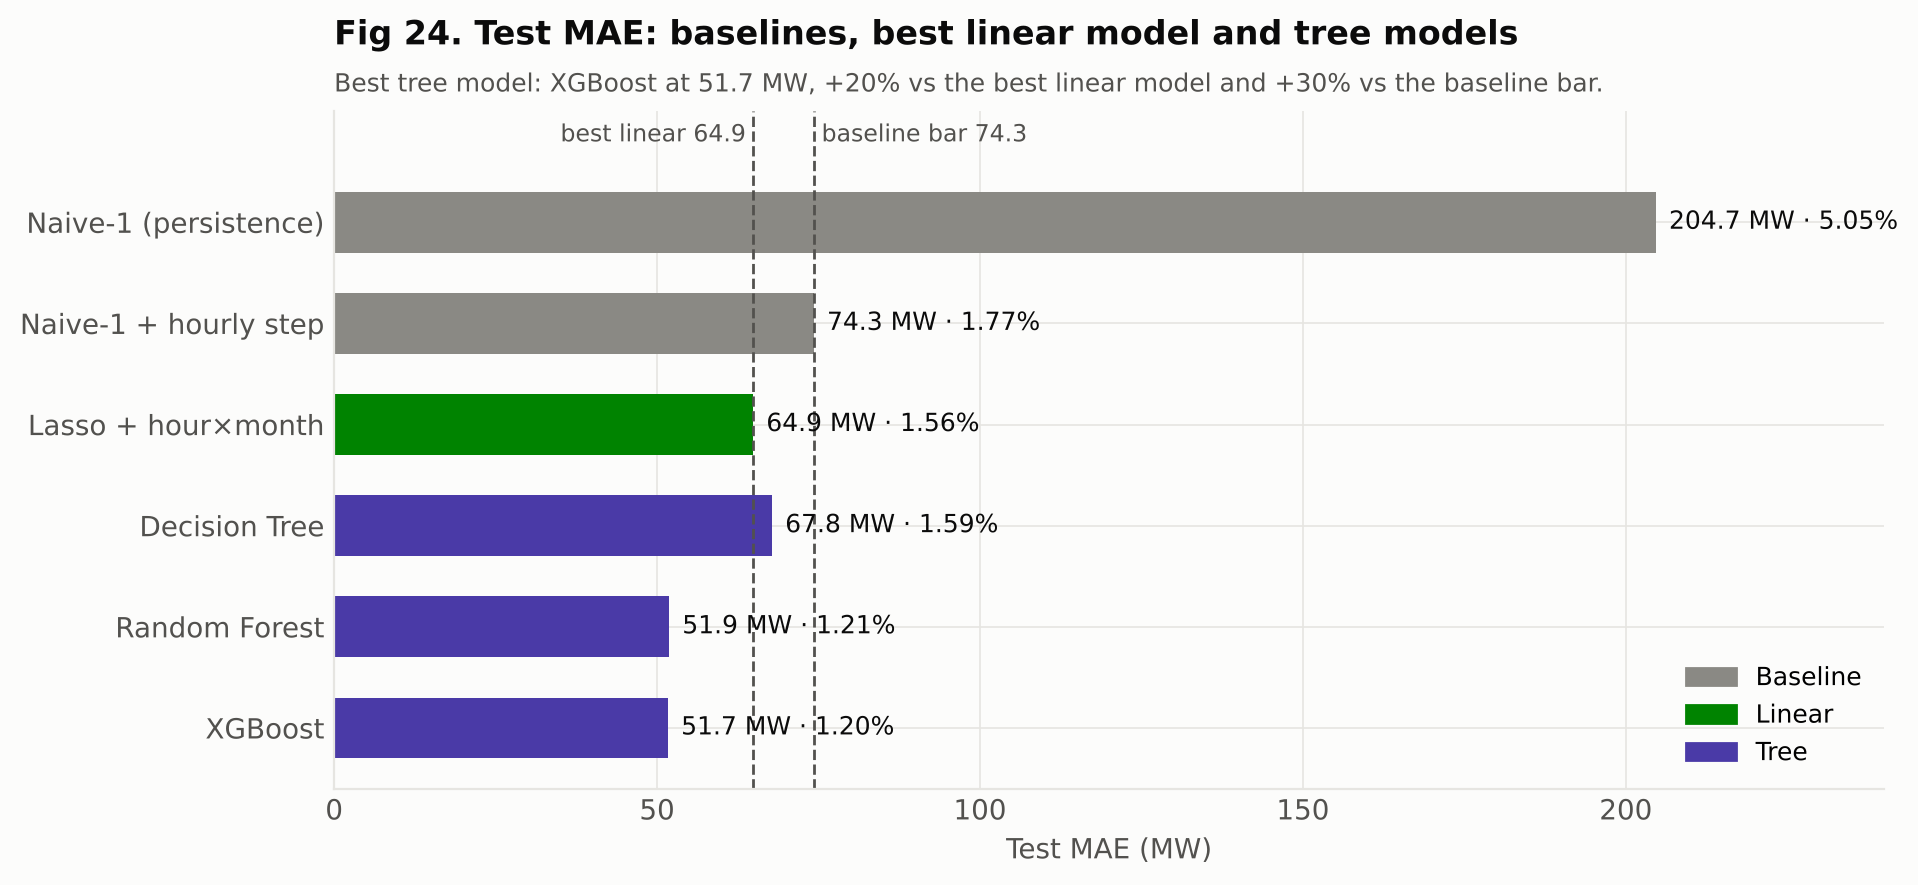

In [10]:
show("F24_results_so_far")

### Peak hours

In [11]:
tab[(tab.split == "test") & (tab.subset == "peak")][["model", "n", "MAE", "MAPE", "Bias"]].sort_values("MAE").reset_index(drop=True)

,model,n,MAE,MAPE,Bias
0,Random Forest,588,52.951,0.811,4.434
1,XGBoost,588,53.652,0.821,8.023
2,Lasso + hour×month,588,62.664,0.955,24.643
3,Naive-1 + hourly step,588,66.256,1.014,8.615
4,XGBoost [level target],588,70.742,1.077,23.471
5,Decision Tree,588,72.621,1.118,2.317
6,Random Forest [level target],588,85.258,1.301,19.200
7,Decision Tree [level target],588,111.771,1.699,15.472
8,Naive-1 (persistence),588,193.482,2.954,46.694


---
## 7. What drives the predictions

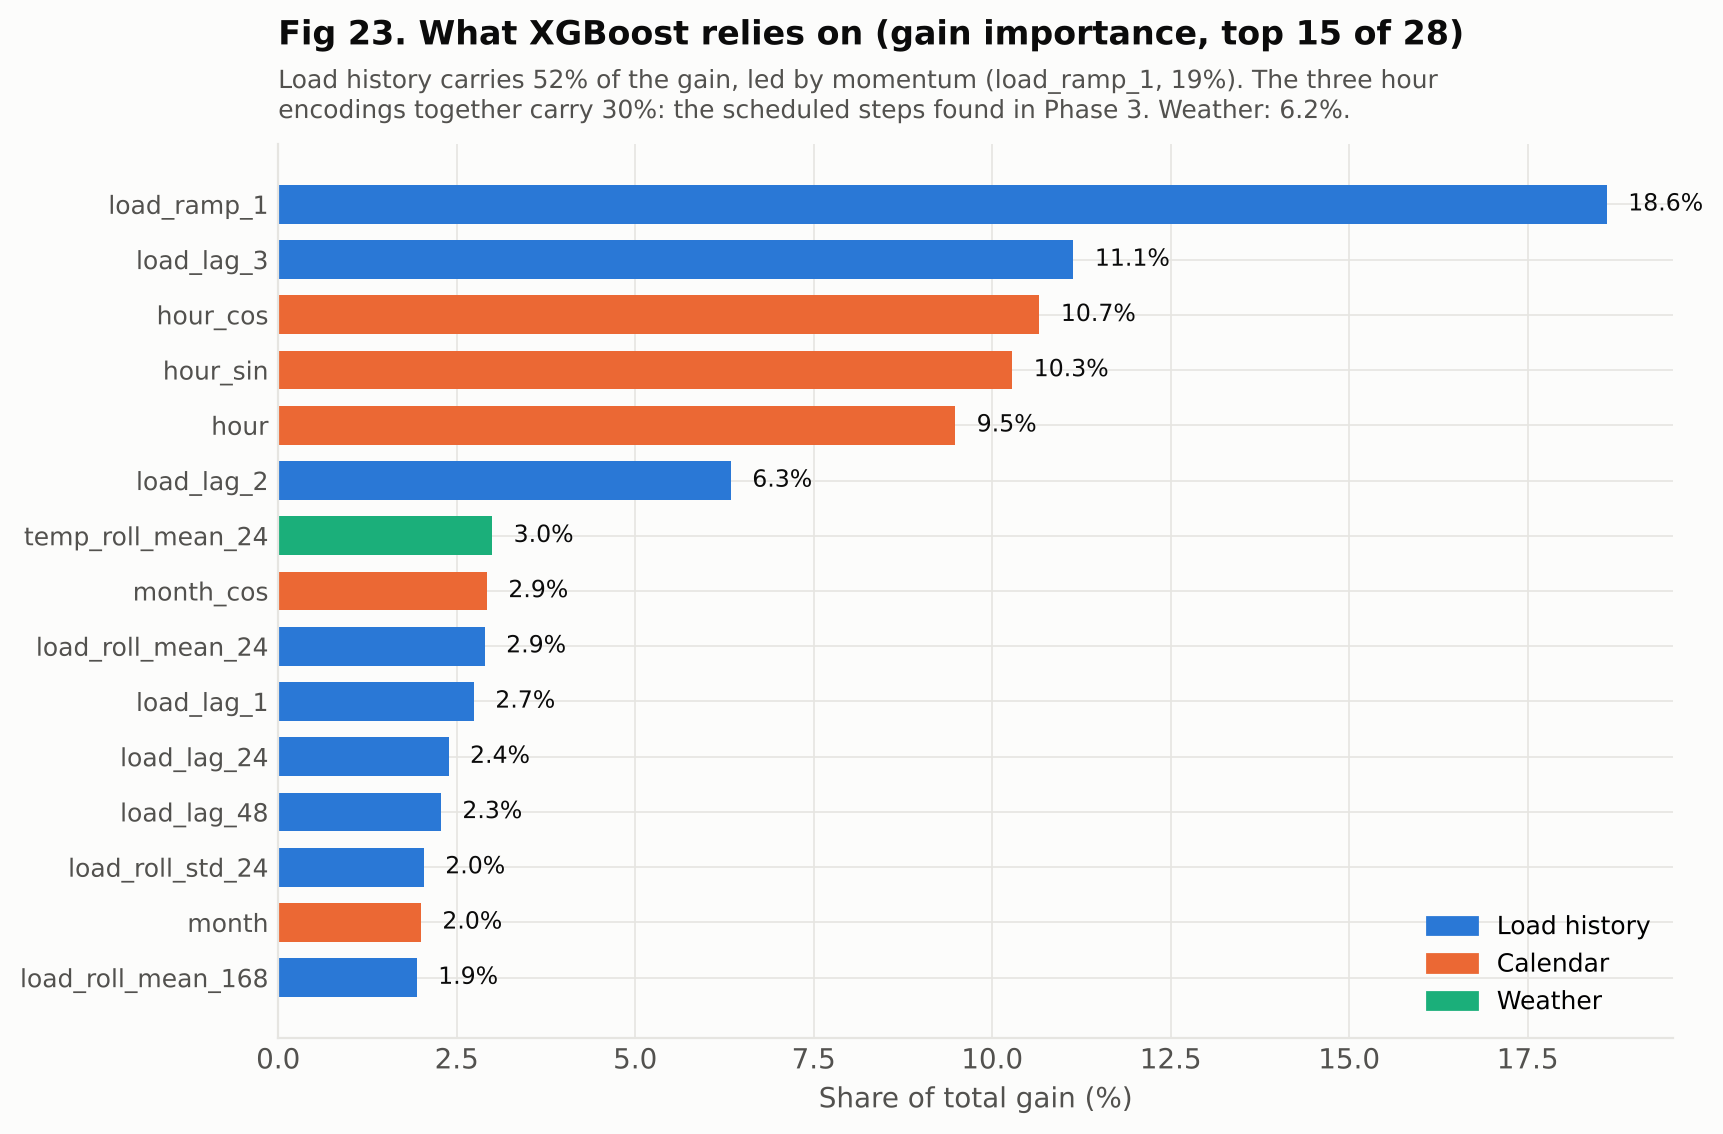

In [12]:
show("F23_xgb_importance", 800)

In [13]:
imp = pd.read_csv(config.TABLE_DIR / "phase5_importance.csv", index_col=0)
grp = lambda c: "Load history" if c in features.LOAD else "Weather" if c in features.WEATHER else "Calendar"
imp.groupby(imp.index.map(grp)).sum().round(3)

,Decision Tree,Random Forest,XGBoost
Calendar,0.273,0.359,0.418
Load history,0.690,0.599,0.520
Weather,0.036,0.042,0.062


💡 **Gain importance** = the total reduction in loss contributed by splits on a feature. It describes *the model*, not causation, and it is spread arbitrarily among correlated features (e.g. the hour encodings). SHAP values in Phase 7 give a per-prediction view.

---
## 8. Summary

| Expectation (written before running) | Result |
|---|---|
| 1. A single tree overfits and won't beat the linear model | ✔ 67.8 vs 64.9 MW; depth sweep (Fig 20) shows the overfitting directly |
| 2. Random Forest beats a single tree (variance reduction) | ✔ 51.9 vs 67.8 MW (−23%) |
| 3. XGBoost is the best tree model and beats 64.9 MW | ◐ beats it (51.7 MW, −20%) but only **ties** Random Forest (0.2 MW apart); significance tested in Phase 7 |

**Further findings**
- **Predicting the change beats predicting the level** for every tree model (XGBoost 64.6 → 51.7 MW), chosen by CV, not by looking at the test set.
- **Peak hours:** the linear model under-forecast peaks by about 25 MW on average; the tree ensembles cut that bias to 4–8 MW, and Random Forest has the lowest peak MAE (53.0 MW).
- **Weather still contributes little** (4–6% of gain in all three models), consistent with the EDA.
- **A lesson about tuning.** Stage 2 improved XGBoost's CV error by 1.4% but its test error got 1.0% *worse*. We still keep the stage-2 model, because choosing by test score would be leakage. Beyond a point, extra tuning chases noise in the CV folds; hence the one-stage stopping rule.

**New reference for Phase 6 (MLP): ≈ 51.7 MW.**